# Metrics
Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt

datadir = "/jukebox/hasson/snastase/social-ctf/results"
# classification of coop/comp pairs
pc_clf_results = np.load(f'{datadir}/clf-pair_X-pc_spi-fast_matchup-0.npy', allow_pickle=True).item()
pc_clf_wins = np.load(f'{datadir}/clf-win_X-pc_spi-fast_matchup-0.npy', allow_pickle=True).item()

clf_results = np.load(f'{datadir}/clf-pair_X-all_spi-fast_matchup-0.npy', allow_pickle=True).item()
clf_wins = np.load(f'{datadir}/clf-win_X-all_spi-fast_matchup-0.npy', allow_pickle=True).item()

In [3]:
ls /jukebox/hasson/snastase/social-ctf/results/clf-win*

/jukebox/hasson/snastase/social-ctf/results/clf-win_X-all_spi-fast_matchup-0.npy
/jukebox/hasson/snastase/social-ctf/results/clf-win_X-pc_spi-fast_matchup-0.npy


In [4]:
clf_wins['pearsonr']

array([0.53125 , 0.671875, 0.625   , 0.71875 , 0.484375, 0.578125,
       0.703125, 0.671875, 0.5625  , 0.515625, 0.5625  , 0.53125 ,
       0.53125 , 0.578125, 0.609375, 0.515625, 0.640625, 0.5625  ,
       0.546875, 0.59375 , 0.59375 , 0.578125, 0.625   , 0.5625  ,
       0.578125, 0.46875 , 0.53125 , 0.6875  , 0.671875, 0.625   ,
       0.703125, 0.609375])

In [5]:
results_wins_multi = np.load('results_wins_multi.npy')

In [6]:
temp = np.mean(results_wins_multi, axis=0)
temp

0.7158203125

In [7]:
pearsonr(temp, clf_wins['pearsonr'])

NameError: name 'pearsonr' is not defined

In [ ]:
import json

with open(f'{datadir}/fav_spi_keywords.json', 'r') as f:
    fav_spis = json.load(f)
fav_spis

{'anm': {'keywords': ['directed',
   'nonlinear',
   'unsigned',
   'bivariate',
   'contemporaneous',
   'causal'],
  'name': 'additive noise model'},
 'ce_gaussian': {'keywords': ['undirected',
   'nonlinear',
   'unsigned',
   'bivariate',
   'contemporaneous',
   'information'],
  'name': 'conditional entropy'},
 'cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5': {'keywords': ['undirected',
   'linear',
   'unsigned',
   'bivariate',
   'frequency-dependent',
   'spectral'],
  'name': 'coherence magnitude'},
 'coint_aeg_tstat_trend-ct_autolag-bic_maxlag-10': {'keywords': ['undirected',
   'linear',
   'unsigned',
   'bivariate',
   'time-dependent'],
  'name': 'cointegration'},
 'coint_johansen_max_eig_stat_order-0_ardiff-1': {'keywords': ['undirected',
   'linear',
   'unsigned',
   'bivariate',
   'time-dependent',
   'miscellaneous'],
  'name': 'cointegration'},
 'cov_EmpiricalCovariance': {'keywords': ['undirected',
   'linear',
   'signed',
   'multivariate',
   'contemporaneous',

Metrics over PCs

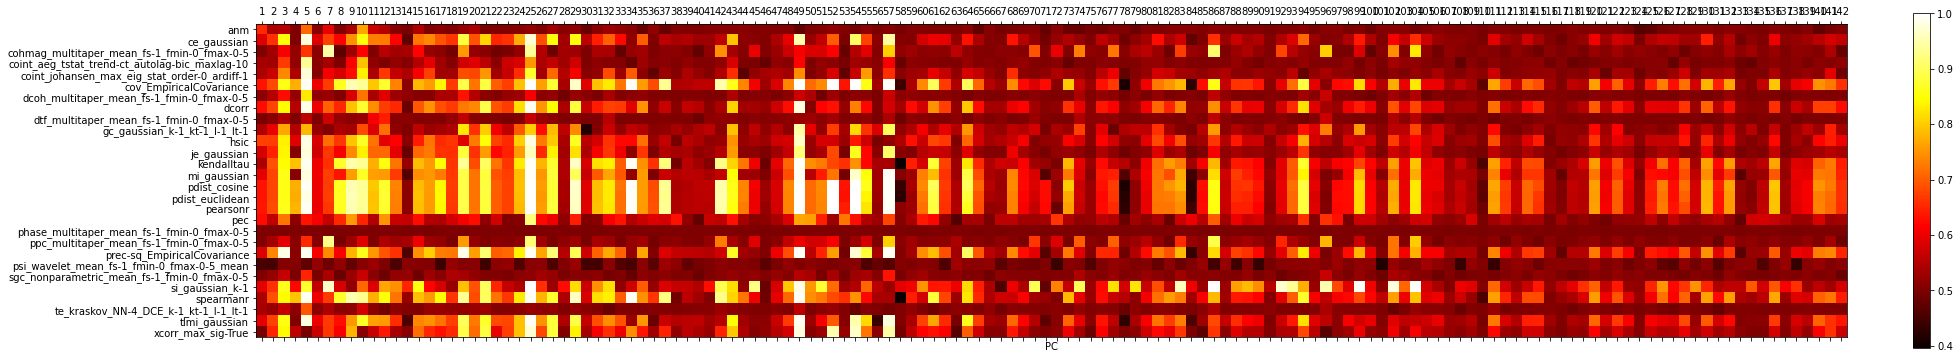

In [39]:
num_pcs = 142
means = np.empty(shape=(0,num_pcs))
labels=[]

for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    #filter metrics that are ineffective
    if np.mean(np.array(pc_clf_results[1][metric]))==0.5:
        continue
        
    temp = []
    labels.append(metric)
    for pc in range(num_pcs):
        temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
    temp=np.array(temp)[np.newaxis,:]
    means = np.concatenate((means, temp), axis=0)
    
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(means, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(num_pcs))
ax.set_xticklabels([i for i in range(1,143)]);
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels);
fig.savefig("all_metrics.png")

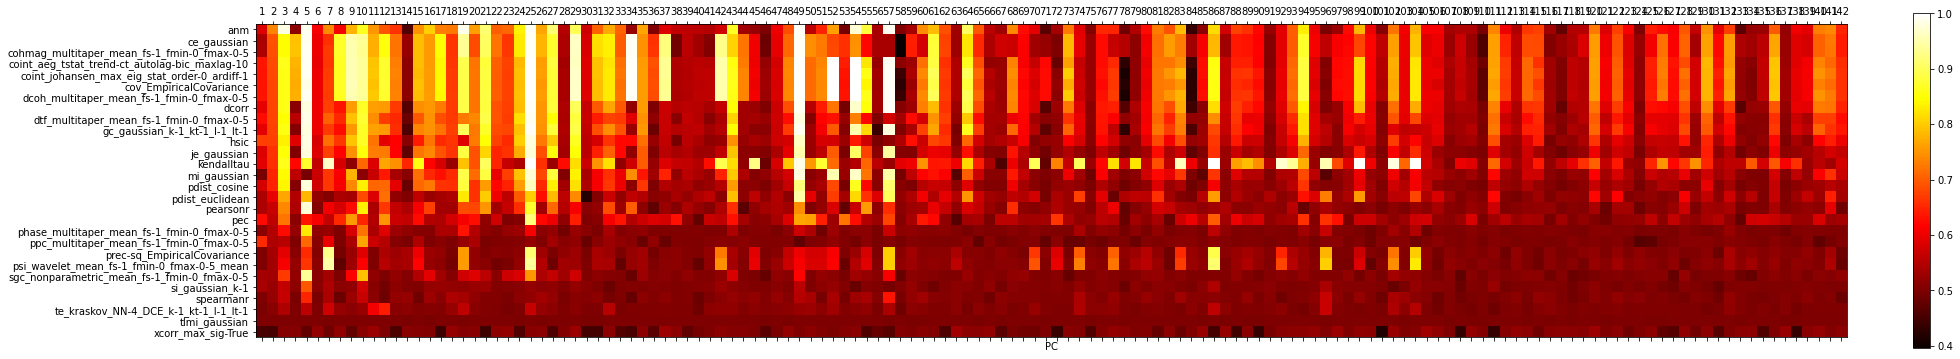

In [38]:
means_sort = means[means[:,1].argsort()[::-1], :]
    
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(means_sort, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(num_pcs))
ax.set_xticklabels([i for i in range(1,143)]);
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels);

fig.savefig("all_metrics_sorted.png")

In [11]:
means.shape

(28, 142)

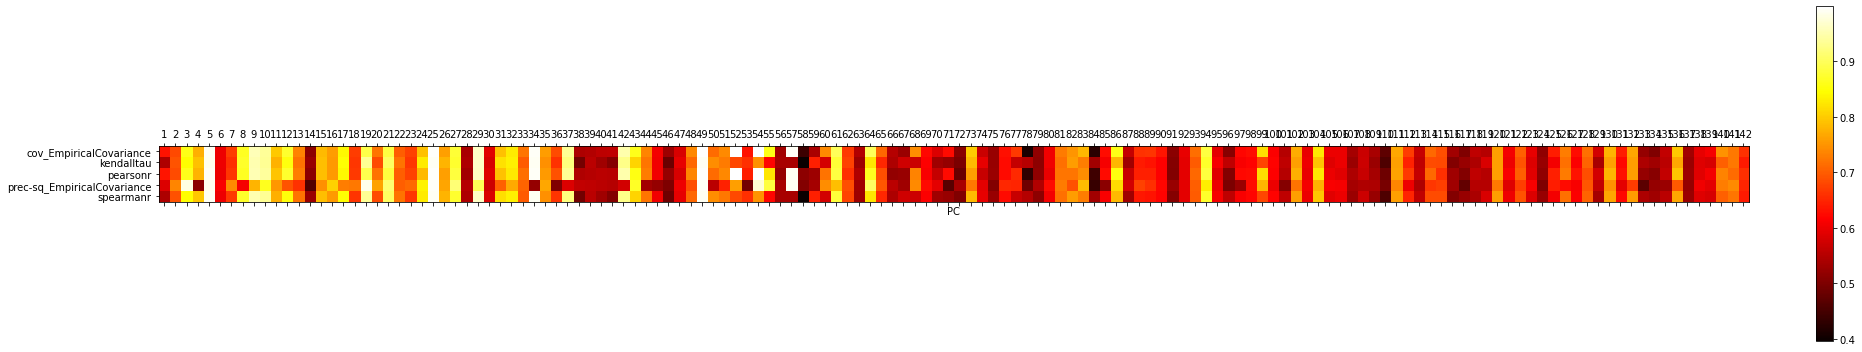

In [41]:
means_signed = np.empty(shape=(0,num_pcs))
labels_signed=[]

for metric in fav_spis:
    if 'signed' in fav_spis[metric]['keywords']:
        temp = []
        labels_signed.append(metric)
        for pc in range(num_pcs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        means_signed = np.concatenate((means_signed, temp), axis=0)
        
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(means_signed, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(num_pcs))
ax.set_xticklabels([i for i in range(1,143)]);
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels_signed)))
ax.set_yticklabels(labels_signed);
fig.savefig("signed_metrics.png")

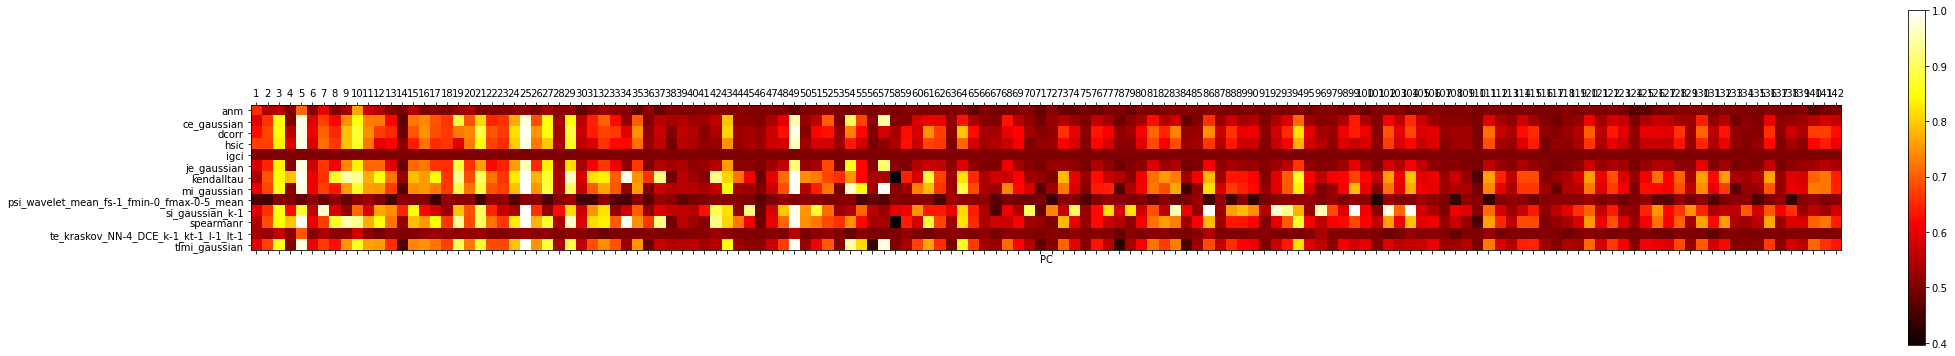

In [42]:
means_nonlinear = np.empty(shape=(0,num_pcs))
labels_nonlinear=[]

for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    if 'nonlinear' in fav_spis[metric]['keywords']:
        temp = []
        labels_nonlinear.append(metric)
        for pc in range(num_pcs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        means_nonlinear = np.concatenate((means_nonlinear, temp), axis=0)
        
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(means_nonlinear, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(num_pcs))
ax.set_xticklabels([i for i in range(1,143)]);
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels_nonlinear)))
ax.set_yticklabels(labels_nonlinear);
fig.savefig("nonlinear_metrics.png")

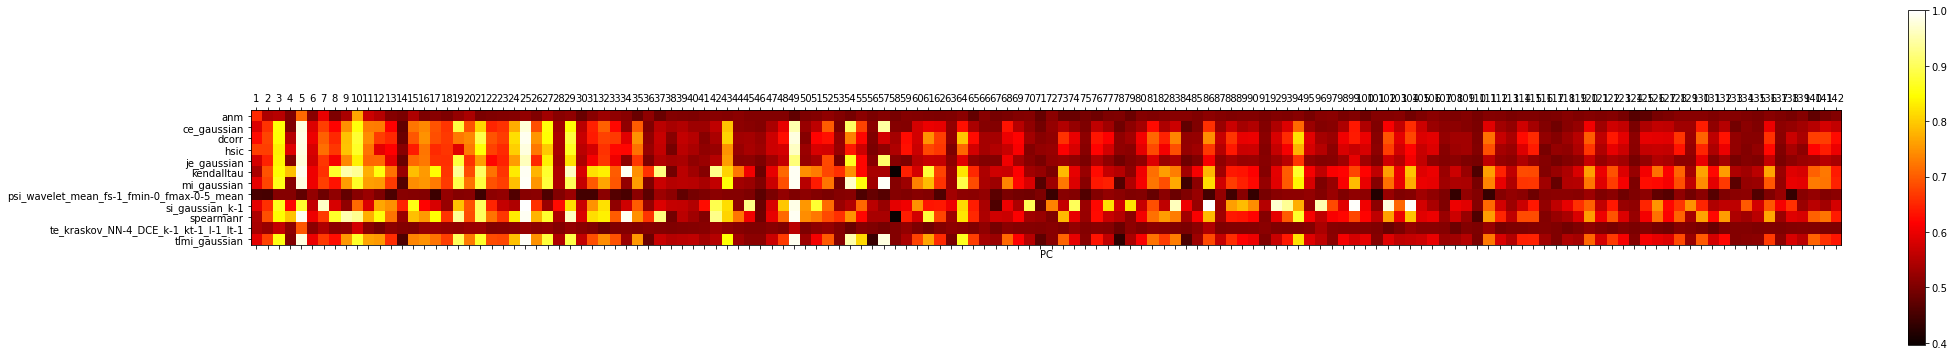

In [ ]:
means_nonlinear = np.empty(shape=(0,num_pcs))
labels_nonlinear=[]

for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    #filter metrics that are ineffective
    if np.mean(np.array(pc_clf_results[1][metric]))==0.5:
        continue
        
    if 'nonlinear' in fav_spis[metric]['keywords']:
        temp = []
        labels_nonlinear.append(metric)
        for pc in range(num_pcs):
            temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
        temp=np.array(temp)[np.newaxis,:]
        means_nonlinear = np.concatenate((means_nonlinear, temp), axis=0)
        
fig,ax = plt.subplots(figsize=(30,10))
n=ax.matshow(means_nonlinear, cmap='hot') 
fig.colorbar(n,fraction=0.01, pad=0.04)
ax.set_xticks(np.arange(num_pcs))
ax.set_xticklabels([i for i in range(1,143)]);
ax.set_xlabel('PC')
ax.set_yticks(np.arange(len(labels_nonlinear)))
ax.set_yticklabels(labels_nonlinear);
fig.savefig("nonlinear_metrics_filtered.png")

Metrics Correlations

In [15]:
from scipy.stats import pearsonr

corrs = np.full((means.shape[0], means.shape[0]), np.nan)

i=0
for metric in fav_spis:
    if metric == 'pearsonr-sq':
        continue
    #filter metrics that are ineffective
    elif np.mean(np.array(pc_clf_results[1][metric]))==0.5:
        continue
        
    temp=[]
    for pc in range(num_pcs):
        temp.append(np.mean(np.array(pc_clf_results[pc][metric])))
    temp=np.array(temp)#[np.newaxis,:]
    
    j=0
    for metric2 in fav_spis:
        if metric2 == 'pearsonr-sq':
            continue
        #filter metrics that are ineffective
        elif np.mean(np.array(pc_clf_results[1][metric2]))==0.5:
            continue
            
        temp2=[]
        for pc in range(num_pcs):
            temp2.append(np.mean(np.array(pc_clf_results[pc][metric2])))
        temp2=np.array(temp2)#[np.newaxis,:]
        
        corrs[i][j] = pearsonr(temp, temp2)[0]
        
        j+=1
    i+=1

In [16]:
corrs_sort = corrs[corrs[1,:].argsort(), :]
corrs_sort = corrs_sort[:, corrs[:,1].argsort()]
corrs_sort.shape

(28, 28)

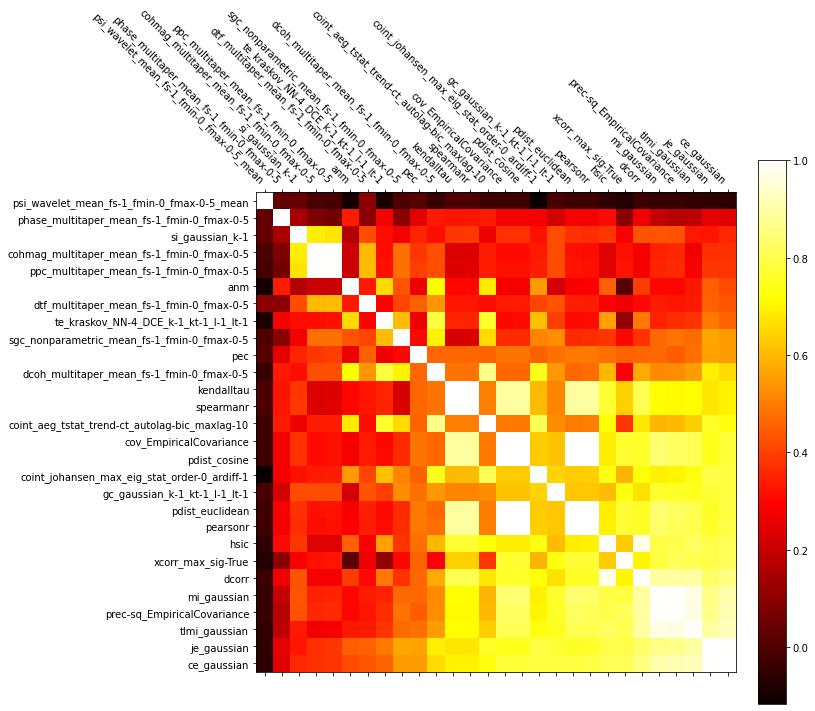

In [29]:
fig,ax = plt.subplots(figsize=(10,10))
n=ax.matshow(corrs_sort, cmap='hot') 
fig.colorbar(n,fraction=0.1, pad=0.04)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(np.array(labels)[corrs[1,:].argsort()]);#['']*28);
plt.xticks(rotation=-45, ha='right')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(np.array(labels)[corrs[1,:].argsort()]);
fig.savefig("all_metrics_correlation.png")

In [ ]:
fig,ax = plt.subplots(figsize=(10,10))
n=ax.matshow(corrs, cmap='hot') 
fig.colorbar(n,fraction=0.1, pad=0.04)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels);
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels);